# Echotype Extraction Notebook

This notebook implements an iterative workflow to segment user-defined regions of interest (ROIs) into *echotypes*, i.e. subset of those regions caracterised by both spatio-temporal (echogram shape) and frequencial (as per the acoustic frequency-response) homogeneity.

In [1]:
import numpy as np
import random

random_seed = 42

np.random.seed(random_seed)
random.seed(random_seed)


## Input data

Two files are required to perform echotypes extraction: an acoustic data file and an annotation file.

1. The acoustic data file is formatted as an [echopype](https://echopype.readthedocs.io/en/latest/) L3 product i.e. averaged Sv data, or MVBS.
2. The annotation file is contains information about the polygonal shapes defining the ROIs. It has to be compatible with Echoregions' [Regions2D](https://echoregions.readthedocs.io/en/latest/api/echoregions.regions2d.Regions2D.html) class.

First we load the input data using `xarray` and the `echoregions.read_regions_csv` function.

In [124]:
import xarray as xr
import echoregions as er
from echoregions.regions2d import Regions2D

ds_MVBS: xr.Dataset = xr.open_dataset("/Users/gaspardringuenet/Data/tapioca/Abracos_A2/Abracos_A2_10s1m.zarr")
regions: Regions2D = er.read_regions_csv("/Users/gaspardringuenet/Desktop/ab2_results/ab2_regions_10s1m.csv")

## Initialize workflow

The `EchotypeWorflow` class contains all methods to iterate trough the ROIs dataset and extract echotypes. To initialize the worflow, we create an instance of this class and pass the input data, as well a path to the results_directory (changing the pass create an independant worflow).

The object also provide information about the process' state (typically the ROIs' processing status). We can print a report using the `.status_report` method. This will show us how much work is left, and where we last stopped.

In [125]:
from escore.echotypes.workflow import EchotypeWorkflow

workflow = EchotypeWorkflow(ds_MVBS.drop_isel(channel=3), regions, results_dir='../private/worflow-test')

In [774]:
workflow.status_report()

Workflow status reports:
Out of 188 regions, 19 (10.1%) have been processed.
 * 14 marked as completed (echotypes have been extracted)
 * 5 marked as rejected (skipped without extracting)
 * 169 remain pending
Last loaded region id: 20


## Processing loop

We enter the processing loop by setting up the **current** region id using the `.set_current` method. The workflow instance will then operate on this region without having to pass the argument again.

When calling `.set_current` on a region for the first time, an instance of `CurrentRegion` is created (and stored as the worflow's `.current_` attribute):

```python
@dataclass
class CurrentRegion:
    # Id & input
    region_id: int
    region_data: xr.DataArray

    # Worflow outputs
    segmenter: Pipeline | None = None
    segments: xr.DataArray | None = None
    segment_id: int | None = None
    echotype_data: xr.DataArray | None = None
```

This class will track and store our progress when processing the ROI. Its attributes illustrate the workflow steps:

1. Region data is selected from the input dataset
2. A segmentation pipeline is defined
3. Region data is segmented and segments are stored
4. The user selects a segment & which defined the echotype_data

If the user approves, echotype data, segmenter & recipe are stored in the resuts directory.

## Step 1 - Set current region & inspect echogram

If a region's results have been saved, the `CurrentRegion` instance is populated with the saved data.

In [713]:
REGION_ID = 20
workflow.set_current(region_id=REGION_ID)

Switching current id from 19 to 20. Unsaved changes for the previous echotype are dropped. 
No saved recipe to load.
Ready for processing!


In [714]:
if workflow.current_.echotype_data is not None: # type: ignore
    workflow.plot.echotype_rgb()

Saving automatically changes the region's processing status to "completed". However, an echotype can be first saved, then marked as "rejected" later. In such case, beware that the "rejected" data is loaded when setting current. Using `.reset_current` is then advisable to enforce the coherence of workflow output in the `CurrentRegion` instance.

In [715]:
# workflow.reset_current()

The user can then plot echograms of the selected region using `.plot.input`. One can select whether to plot the ROI data only or show the ROI bbox & polygon using the `how` keyword argument. Switching between xarray's plotting interfaces (`plot` or `hvplot`) it allowed using the `plot_api` keyword argument. Finally the user can provide `plot_kwrgs` which will be passed to the selected plotting API.

Alternatively, the `.plot.input_rgb` method display and **RGB echogram**: a multifrequency visualization tool mapping 3 frequency channels to the red, green and blue channels of the image. This method uses directly `matplotlib.pyplot.pcolormesh`.

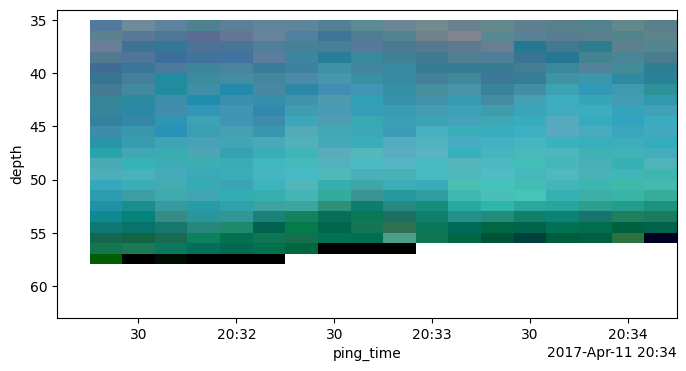

In [716]:
workflow.plot.input_rgb(how='exact') # alternatively use workflow.plot.input()

## Step 2 - ROI segmentation

### Segmentation pipeline

Extracting an echotype from the region of interest is done using a [scikit-learn](https://scikit-learn.org/stable/) [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline). Among other benefits, this fosters reproducibility as pipelines can be easily saved to and loaded from disk.

Pipeline definition follows scikit-learn synthax. The `escore` package provides a custom transformer called `SvDifferenceExtractor` which subtract a feature columns to the others. In acoustics terms, it computes the frequency response $R(f)$ for each observation:

$$
R(f) = \Delta \text{MVBS} = \text{MVBS}_{\text{channel} \neq \text{ref}} - \text{MVBS}_{\text{channel} = \text{ref}}
$$

The model is then passed to the worflow using the `.set_segmenter` method. The `.segment` method both fits the segmenter & predicts ROI segments.

Note: `.segment` also enforce compatibility between the pipeline and acoustic data, namely by flattening the depth and time dimension. The data fed to the model is in shape `(depth.size * time.size, n_channels)`. Channels are not reordered in the process. Knowing the channels' indices is required to correctly specify the `ref_channel_idx` of `SvDifferenceExtract` (0 by default).

In [764]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from escore.estimators.transformers import SvDifferenceExtractor

N = 3

segmentation_model = Pipeline([
    ('features', SvDifferenceExtractor()),
    ('scaler', StandardScaler()),
    # ('clf', KMeans(n_clusters=N, random_state=random_seed)),
    ('clf', GaussianMixture(n_components=N, random_state=random_seed)),
])

workflow.set_segmenter(segmenter=segmentation_model)

_ = workflow.segment()

### Validate segmentation

The simplest validation criterion is visual coherence of the segments. Similarly to the input, the user can call `.plot.segments` and `.plot.segments_rgb` to visualize the segmentation results.

Using those methods, we can get a good intuition of whether or not we were able to segment the desired object.

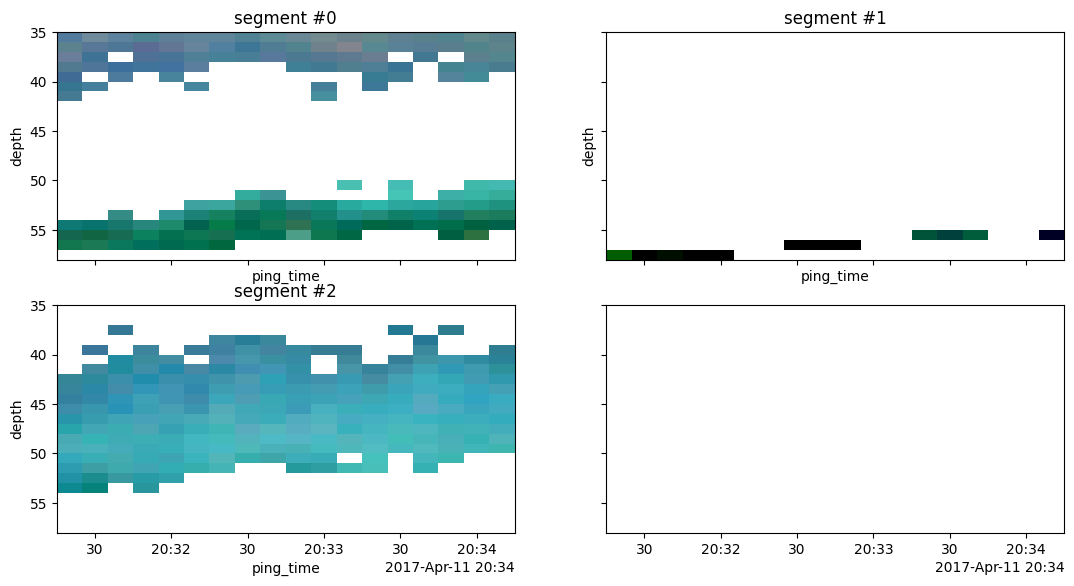

In [765]:
workflow.plot.segments_rgb(figsize=(13, 6.5), ncols=2)

## Step 3 - Select and validate echotype

### Selection

We use `.select_segment` to save a segment as the `echotype_data` field of the `CurrentRegion` object.

In [766]:
SEGMENT_ID = 2
echotype_da = workflow.select_segment(SEGMENT_ID)

Using segment 2 as echotype data.


### Validation

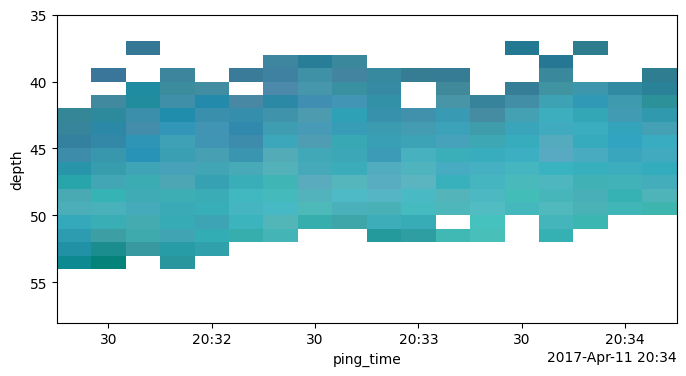

In [767]:
# workflow.plot.echotype(plot_api='plot', figsize=(15, 5), sharex=False);
workflow.plot.echotype_rgb()

In [768]:
channel_values = list(workflow.data["frequency_nominal"].values / 1e3)

# Absolute frequency response curve
afr = (
    workflow.plot.echotype_frequency_response(None, channel_values)
    .opts(
        ylim=(-85, -55),
        xlabel="Frequency [kHz]", 
        ylabel="Sv [dB]",
        title="Absolute Frequency Response", 
        show_grid=True,
        width=400, 
    )
)
# Relative frequency response curve
rfr = (
    workflow.plot.echotype_frequency_response(0, channel_values)
    .opts(
        ylim=(-15, 15),
        xlabel="Frequency [kHz]", 
        ylabel="ΔSv [dB]", 
        title='Relative Frequency Response', 
        show_grid=True,
        width=400, 
    )
)
# Relative frequency response histogram
rfr_hist = (
    workflow.plot.echotype_frequency_response_hist(0, channel_values, "Frequency [kHz]", legend="top_left", normed=False)
    .opts(
        xlim=(-15, 15), 
        xlabel="ΔSv [dB]", 
        ylabel="Sample count", 
        title="Histogram of R(f)", 
        show_grid=True,
        width=500, 
    )
)

(afr + rfr + rfr_hist).opts(shared_axes=False)

:Layout
   .Overlay.I   :Overlay
      .Curve.I     :Curve   [channel]   (mean)
      .Scatter.I   :Scatter   [channel]   (mean)
      .ErrorBars.I :ErrorBars   [channel]   (mean,sd)
   .Overlay.II  :Overlay
      .Curve.I     :Curve   [channel]   (mean)
      .Scatter.I   :Scatter   [channel]   (mean)
      .ErrorBars.I :ErrorBars   [channel]   (mean,sd)
   .NdOverlay.I :NdOverlay   [Frequency [kHz]]
      :Histogram   [value]   (Count)

Other plots can be generated easily after fetching the echotype formatted as a `DataFrame`.

In [769]:
# workflow.get_echotype_dataframe(['group_id'])

## Step 4 - Save echotype or reject region

In [770]:
raise Exception("Stopping notebook")

Exception: Stopping notebook

In [771]:
# Mark echotype as completed and save results
COMPLETE = True
# Mark region as rejected: can be applied at the same time as COMPLETE (results saved but marked as rejected)
REJECT = False
# Overwrite an already saved echotype   
OVERWRITE = False

In [772]:
if COMPLETE:
    workflow.save_current(OVERWRITE)
if REJECT:
    workflow.mark_rejected()
if not (COMPLETE or REJECT):
    raise ValueError("User not ready to either complete processing or reject region. Stopping execution.")

Region 20 worflow status updated to 'completed'.
Echotype data & recipe saved successfully!


## Export all echotypes as `DataFrame`

In [773]:
raise Exception("Stopping notebook")

Exception: Stopping notebook

In [775]:
# Get all "completed" echotypes as as DataFrame
results_df = workflow.export_completed(add_region_cols=['group_id'])

# Export in any pandas IO format
results_df.to_parquet("../private/echotypes_10s1m.parquet")

results_df

channel,echotype_id,depth,ping_time,channel_0_Sv,channel_1_Sv,channel_2_Sv,region_id,region_class,group_id
0,0,92.5,2017-04-09 19:21:50,-80.811577,-79.551941,-74.050537,1,ROI,NaN
1,0,92.5,2017-04-09 19:22:10,-81.659012,-77.173927,-72.887970,1,ROI,NaN
2,0,92.5,2017-04-09 19:22:20,-84.401222,-76.918617,-71.424271,1,ROI,NaN
3,0,92.5,2017-04-09 19:22:50,-82.186951,-78.460564,-75.292358,1,ROI,NaN
4,0,92.5,2017-04-09 19:23:00,-80.375664,-76.657219,-76.493408,1,ROI,NaN
...,...,...,...,...,...,...,...,...,...
220,19,52.5,2017-04-11 20:31:50,-83.883026,-65.511597,-63.809650,20,ROI,NaN
221,19,52.5,2017-04-11 20:32:00,-82.454994,-64.908020,-63.266811,20,ROI,NaN
222,19,53.5,2017-04-11 20:31:20,-87.905518,-68.312386,-67.264923,20,ROI,NaN
223,19,53.5,2017-04-11 20:31:30,-89.199661,-69.438217,-70.643265,20,ROI,NaN
